In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW = Path("../data/raw")
PRO = Path("../data/processed")

def latest_file(dirpath: Path, patterns=("*.parquet", "*.csv")) -> Path:
    files = []
    for pat in patterns:
        files.extend(dirpath.glob(pat))
    if not files:
        raise FileNotFoundError(f"No CSV/Parquet files found in {dirpath.resolve()}")
    return max(files, key=lambda p: p.stat().st_mtime)

search_dir = PRO if PRO.exists() else RAW
src = latest_file(search_dir)

def read_any(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        # If your environment lacks pyarrow/fastparquet, this will error — tell me if it does.
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file type: {path.suffix}")

df = read_any(src)

print(f"Loaded: {src}")
print("Shape:", df.shape)
display(df.head(3))


expected = {"revenue", "risk_score", "n_clients"}
missing = [c for c in expected if c not in df.columns]
if missing:
    print("Heads up — missing expected columns:", missing)
    print("Your columns are:", list(df.columns)[:15], "...")
    # If names differ, you can map them here. Example:
    # df = df.rename(columns={"clients":"n_clients","risk":"risk_score"})


Loaded: ..\data\processed\homework_eda_sample.parquet
Shape: (500, 6)


,date,sector,region,revenue,risk_score,n_clients
0,2023-01-01,Energy,EU,17409.394782,65.477078,24
1,2023-01-02,Retail,APAC,20881.933888,46.863201,22
2,2023-01-03,Tech,US,33806.169246,51.446000,19


In [4]:
df['rev_per_client'] = df['revenue'] / df['n_clients']

print("Shape after feature:", df.shape)
display(df[['revenue', 'n_clients', 'rev_per_client']].head(5))


Shape after feature: (500, 7)


,revenue,n_clients,rev_per_client
0,17409.394782,24,725.391449
1,20881.933888,22,949.178813
2,33806.169246,19,1779.272066
3,17446.245719,20,872.312286
4,30973.850512,23,1346.689153


In [9]:
# 7-day rolling average of revenue
df = df.sort_values("date")  # ensure proper date order
df['revenue_rolling'] = df['revenue'].rolling(window=7, min_periods=1).mean()

print("Shape after feature:", df.shape)
display(df[['date', 'revenue', 'revenue_rolling']].head(10))


Shape after feature: (500, 10)


,date,revenue,revenue_rolling
0,2023-01-01,17409.394782,17409.394782
1,2023-01-02,20881.933888,19145.664335
2,2023-01-03,33806.169246,24032.499305
3,2023-01-04,17446.245719,22385.935908
4,2023-01-05,30973.850512,24103.518829
5,2023-01-06,8705.454397,21537.174757
6,2023-01-07,20091.420687,21330.638461
7,2023-01-08,28318.087263,22889.023102
8,2023-01-09,36609.030306,25135.751161
9,2023-01-10,15876.738240,22574.403875


In [11]:
# Feature 3 Riskadjusted revenue
# scale risk_score so that higher risk penalizes revenue
df['risk_adj_revenue'] = df['revenue'] * (100 - df['risk_score']) / 100

print("Shape after feature:", df.shape)
display(df[['revenue', 'risk_score', 'risk_adj_revenue']].head(5))


Shape after feature: (500, 11)


,revenue,risk_score,risk_adj_revenue
0,17409.394782,65.477078,6010.231722
1,20881.933888,46.863201,11095.991258
2,33806.169246,51.446000,16414.247583
3,17446.245719,37.655908,10876.703481
4,30973.850512,NaN,NaN


In [12]:
from datetime import datetime

# --- build filename with timestamp for reproducibility
ts = datetime.now().strftime("%Y%m%d-%H%M")
out_path = Path("../data/processed") / f"features_{ts}.parquet"

df.to_parquet(out_path, index=False)

print("Saved to:", out_path)


Saved to: ..\data\processed\features_20250823-2107.parquet


### Feature 1  rev_per_client
**What:** revenue divided by number of clients.  
**Why:** normalizes for client base size to capture efficiency / value per client.  
**Risk:** sensitive to very small `n` values.

### Feature 2 revenue_rolling
**What:** 7‑day rolling mean of revenue.  
**Why:** smooths daily noise and exposes short‑term momentum.  
**Risk:** introduces look‑back smoothing; pick window based on business cadence.

### Feature 3 risk_adj_revenue
**What:** revenue scaled by (1 − risk_score/100).  
**Why:** combines return and risk into a single comparable metric.  
**Risk:** assumes linear penalty of risk, risk may be nonlinear.


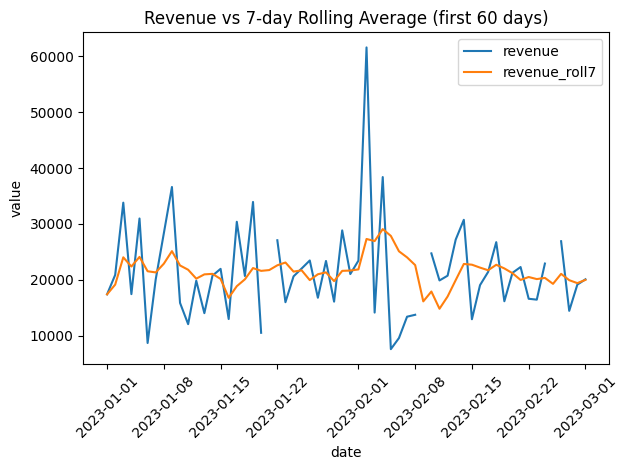

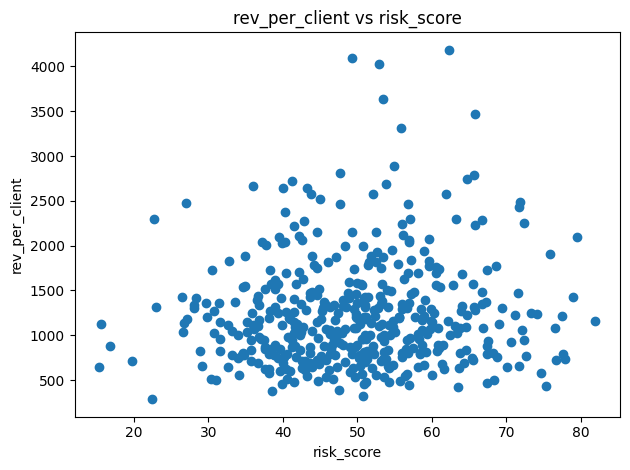

In [21]:
import matplotlib.pyplot as plt

# revenue vs rolling average (60 days)
sample = df.sort_values('date').head(60)

plt.figure()
plt.plot(sample['date'], sample['revenue'], label='revenue')
plt.plot(sample['date'], sample['revenue_roll7'], label='revenue_roll7')
plt.title('Revenue vs 7‑day Rolling Average (first 60 days)')
plt.xlabel('date'); plt.ylabel('value'); plt.legend(); plt.xticks(rotation=45)
plt.tight_layout()
# risk vs per‑client
plt.figure()
plt.scatter(df['risk_score'], df['rev_per_client'])
plt.title('rev_per_client vs risk_score')
plt.xlabel('risk_score'); plt.ylabel('rev_per_client')
plt.tight_layout()
